In [2]:
import time
import warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, randint
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.utils import resample
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import uniform, loguniform, t, sem
import tensorflow as tf
import keras_tuner as kt
from pyMAISE.datasets import load_MITR
from pyMAISE.preprocessing import correlation_matrix, train_test_split, scale_data
import pyMAISE as mai

# Set display option to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Set the width of the columns
pd.set_option('display.width', None)

# See the full content of each column
pd.set_option('display.max_colwidth', None)

# Plot settings
matplotlib_settings = {
    "font.size": 12,
    "legend.fontsize": 11,
    "figure.figsize": (12, 8)
}
plt.rcParams.update(**matplotlib_settings)

# Suppress all ConvergenceWarnings
# warnings.filterwarnings("ignore", category=ConvergenceWarning)

print('libraries imported and settings configured')

libraries imported and settings configured


In [3]:
#pyMAISE init
global_settings = mai.init(
    problem_type=mai.ProblemType.REGRESSION,
    random_state=42,
    cuda_visible_devices="=1"
)

print('pyMAISE initialized')

pyMAISE initialized


In [4]:
# load data
data, inputs, outputs = load_MITR()

print('Data loaded')

Data loaded


In [5]:
# Data Bias: Create k-fold cv on train/test sets.
k = 2

kf = KFold(n_splits=k, shuffle=True, random_state=42)
X_train_sets = np.empty((k, (k-1)*inputs.shape[0] // k, inputs.shape[-1]))
X_test_sets = np.empty((k, inputs.shape[0] // k, inputs.shape[-1]))
Y_train_sets = np.empty((k, (k-1)*outputs.shape[0] // k, outputs.shape[-1]))
Y_test_sets = np.empty((k, outputs.shape[0] // k, outputs.shape[-1]))
print(X_train_sets.shape)
print(Y_train_sets.shape)
print(X_test_sets.shape)
print(Y_test_sets.shape)

for n, (train_index, test_index) in enumerate(kf.split(inputs)):
    X_train_sets[n] = inputs[train_index]
    X_test_sets[n] = inputs[test_index]
    Y_train_sets[n] = outputs[train_index]
    Y_test_sets[n] = outputs[test_index]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("fnn", MLPRegressor(max_iter=10, random_state=42))
])

model = TransformedTargetRegressor(
    regressor=pipe,
    transformer=StandardScaler()
)

print('Data preprocessing completed')

(2, 500, 6)
(2, 500, 22)
(2, 500, 6)
(2, 500, 22)
Data preprocessing completed


In [6]:
# Model Bias: Define hyper parameter distributions for random search.
wide_layer_sizes = [
    (64,), (128,), (256,), (512,),
    (128, 128), (256, 256),
    (128, 64), (256, 128),
    (512, 256), (256, 128, 64),
]
narrow_layer_sizes = [
    (8,), (16,), (32,),
    (16, 8), (32, 16),
    (32, 16, 8), (16, 16),
    (24, 12), (12, 12, 12),
    (32, 24, 16),
]
taper_layer_sizes = [
    (256, 128, 64),
    (512, 256, 128),
    (256, 128, 64, 32),
    (128, 64, 32, 16),
    (512, 256, 128, 64),
    (256, 128, 64, 32, 16),
    (128, 96, 64, 32),
    (256, 192, 128, 64),
    (384, 256, 128),
    (192, 128, 64, 32),
]
rev_taper_layer_sizes = [
    (32, 64, 128),
    (64, 128, 256),
    (16, 32, 64, 128),
    (32, 64, 128, 256),
    (8, 16, 32, 64),
    (16, 32, 64, 128, 256),
    (24, 48, 96),
    (32, 96, 192),
    (64, 128, 256, 512),
    (32, 64, 128, 256, 512),
]
bowtie_layer_sizes = [
    (128, 32, 128),
    (256, 64, 256),
    (128, 64, 32, 64, 128),
    (256, 128, 64, 128, 256),
    (64, 16, 64),
    (128, 32, 16, 32, 128),
    (256, 64, 32, 64, 256),
    (192, 64, 192),
    (128, 48, 24, 48, 128),
    (256, 96, 48, 96, 256),
]

activation = ["relu", "tanh"]
alpha = loguniform(1e-5, 1e-1)
learning_rate_init = loguniform(1e-4, 1e-2)
solver = ["adam", 'lbfgs']
early_stopping = [True]
validation_fraction = [0.1]

n_iter = 5
scoring = "r2"
cv = 5
verbose = 1
random_state = 42
n_jobs = -1

wide_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": wide_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha,
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

narrow_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": narrow_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha,
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

taper_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": taper_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha,
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

rev_taper_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": rev_taper_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha,
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

bowtie_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": bowtie_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha, #regularization
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

wide_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=wide_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

narrow_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=narrow_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

taper_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=taper_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

rev_taper_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=rev_taper_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

bowtie_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=bowtie_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

print('Hyperparameter definitions completed')

Hyperparameter definitions completed


In [7]:
# Sampling Bias: Generate multiple training sets with different sampling methods.
def make_bootstrap_train_sets(X_train_sets, Y_train_sets, n_sets=5, random_state=42):
    X_boot_train_sets = np.empty(shape=(n_sets, X_train_sets.shape[0], X_train_sets.shape[1], X_train_sets.shape[2]))
    Y_boot_train_sets = np.empty(shape=(n_sets, Y_train_sets.shape[0], Y_train_sets.shape[1], Y_train_sets.shape[2]))
    for i in np.arange(X_train_sets.shape[0]):
        for j in np.arange(n_sets): # n bootstrap samples per train set
            X_boot, Y_boot = resample(
                X_train_sets[i],
                Y_train_sets[i],
                n_samples=X_train_sets.shape[1],
                replace=True,
                random_state=random_state
            )
            X_boot_train_sets[j, i] = X_boot
            Y_boot_train_sets[j, i] = Y_boot
    return X_boot_train_sets, Y_boot_train_sets

def make_strata(Y, n_bins=2):
    Y = np.asarray(Y)
    binned_outputs = []
    for i in np.arange(Y.shape[1]):
        target_col = Y[:, i]
        edges = np.quantile(
            target_col,
            np.linspace(0, 1, n_bins + 1)
        )
        edges = np.unique(edges)
        binned_col = np.digitize(
            target_col,
            edges[1:-1],
            right=True
        )
        binned_outputs.append(binned_col)
    binned_outputs = np.column_stack(binned_outputs)
    strata = np.array([
        '_'.join(map(str, row))
        for row in binned_outputs
    ])
    return strata
    
def make_stratified_bootstrap_train_sets(X_train_sets, Y_train_sets, n_sets=5, random_state=42):
    X_boot_stratified_train_sets = np.empty(shape=(n_sets, X_train_sets.shape[0], X_train_sets.shape[1], X_train_sets.shape[2]))
    Y_boot_stratified_train_sets = np.empty(shape=(n_sets, Y_train_sets.shape[0], Y_train_sets.shape[1], Y_train_sets.shape[2]))
    for i in np.arange(X_train_sets.shape[0]):
        for j in np.arange(n_sets):
            X_boot_stratified, Y_boot_stratified = resample(
                X_train_sets[i], 
                Y_train_sets[i], 
                replace=True,
                n_samples=X_train_sets.shape[1],
                stratify=make_strata(Y_train_sets[i]),
                random_state=random_state
            )
            X_boot_stratified_train_sets[j, i] = X_boot_stratified
            Y_boot_stratified_train_sets[j, i] = Y_boot_stratified
        return X_boot_stratified_train_sets, Y_boot_stratified_train_sets

print('Sampling functions defined')

Sampling functions defined


In [8]:
# Generate new train sets with different sampling methods 
n_sets = 1
X_bootstrap_train_sets, Y_bootstrap_train_sets = make_bootstrap_train_sets(X_train_sets, Y_train_sets, n_sets=n_sets)
X_stratified_train_sets, Y_stratified_train_sets = make_stratified_bootstrap_train_sets(X_train_sets, Y_train_sets, n_sets=n_sets)

print(X_train_sets.shape, Y_train_sets.shape)
print(X_bootstrap_train_sets.shape, Y_bootstrap_train_sets.shape)
print(X_stratified_train_sets.shape, Y_stratified_train_sets.shape)
print('Sampled train sets created')

(2, 500, 6) (2, 500, 22)
(1, 2, 500, 6) (1, 2, 500, 22)
(1, 2, 500, 6) (1, 2, 500, 22)
Sampled train sets created


In [9]:
def random_search_and_get_predictions(random_search, X_train_sets, Y_train_sets, X_test_sets):
    predictions = np.empty(shape=(X_test_sets.shape[0], X_test_sets.shape[1], Y_train_sets.shape[2]))
    for i in np.arange(X_train_sets.shape[0]):
        random_search.fit(X_train_sets[i], Y_train_sets[i])
        Y_pred = random_search.predict(X_test_sets[i])
        predictions[i] = Y_pred
    return predictions

def get_scores(Y_pred_sets, Y_test_sets, architecture, sampling_method='none'):
    scores = []
    for i in np.arange(Y_pred_sets.shape[0]):
        scores.append({
            "set_index": i,
            "architecture": architecture,
            "sampling_method": sampling_method,
            "r2": r2_score(Y_test_sets[i], Y_pred_sets[i]),
            "mae": mean_absolute_error(Y_test_sets[i], Y_pred_sets[i]),
            "rmse": root_mean_squared_error(Y_test_sets[i], Y_pred_sets[i]),
        })
    return pd.DataFrame(scores)

def get_pred_results(Y_pred_sets, architecture, sampling_method='none'):
    results = []
    for i in np.arange(Y_pred_sets.shape[0]):
        means = np.mean(Y_pred_sets[i], axis=0)
        variances = np.var(Y_pred_sets[i], axis=0)
        stds = np.std(Y_pred_sets[i], axis=0)
        sems = sem(Y_pred_sets[i], axis=0)
        n = Y_pred_sets[i].shape[0]
        c_intervals_lower = means - sems * t.ppf(1.95 / 2.0, n-1)
        c_intervals_upper = means + sems * t.ppf(1.95 / 2.0, n-1)
        for j in np.arange(Y_pred_sets[i].shape[1]):
            results.append({
                "train_test_set_index": i,
                "architecture": architecture,
                "sampling_method": sampling_method,
                "output_index": j,
                "mean": means[j],
                "variances": variances[j],
                "std": stds[j],
                "95_ci_lower": c_intervals_lower[j],
                "95_ci_upper": c_intervals_upper[j],
            })
    return pd.DataFrame(results)

def get_pred_df(Y_pred_sets, architecture, sampling_method='none'):
    df = []
    for i in np.arange(Y_pred_sets.shape[0]):
        for j in np.arange(Y_pred_sets.shape[1]):
            for k in np.arange(Y_pred_sets.shape[2]):
                df.append({
                    "train_test_set_index": i,
                    "architecture": architecture,
                    "sampling_method": sampling_method,
                    "output_index": k,
                    "prediction": Y_pred_sets[i,j,k],
                })
    return pd.DataFrame(df)

print('Data analysis functions defined')

Data analysis functions defined


In [10]:
# Train models - wide
wide_Y_pred_sets = random_search_and_get_predictions(wide_fnn_random_search, X_train_sets, Y_train_sets, X_test_sets)
sampling_methods = ['none', 'bootstrap', 'stratified_bootstrap']
print(f"{sampling_methods[0]} set done")
wide_Y_pred_boot_collection = []
wide_Y_pred_strat_collection = []
for n in np.arange(n_sets):
    wide_Y_pred_boot_collection.append(
        random_search_and_get_predictions(
            wide_fnn_random_search, X_bootstrap_train_sets[n], Y_bootstrap_train_sets[n], X_test_sets
        )
    )
    print(f"{sampling_methods[1]} set {n+1} out of {n_sets} done")
    wide_Y_pred_strat_collection.append(
        random_search_and_get_predictions(
            wide_fnn_random_search, X_stratified_train_sets[n], Y_stratified_train_sets[n], X_test_sets
        )
    )
    print(f"{sampling_methods[2]} set {n+1} out of {n_sets} done")
print("Wide models trained")

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Convergenc

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Convergenc

none set done
Fitting 5 folds for each of 5 candidates, totalling 25 fits


...

/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimiz

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Convergenc

stratified_bootstrap set 1 out of 1 done
Wide models trained


/home/d8tns/FLC_2026_Spring/CE_315/projects/final_project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [11]:
pred_collection = [wide_Y_pred_sets] + wide_Y_pred_boot_collection + wide_Y_pred_strat_collection
dfs = []
for n in np.arange(len(sampling_methods)):
    df = get_scores(pred_collection[n], Y_test_sets, "wide", sampling_methods[n])
    dfs.append(df)
wide_scores_df = pd.concat(dfs)
print(wide_scores_df.shape)
wide_scores_df.head()

(6, 6)


,set_index,architecture,sampling_method,r2,mae,rmse
0,0,wide,none,0.995241,13.178104,17.483552
1,1,wide,none,0.994310,13.923978,18.766529
0,0,wide,bootstrap,0.994867,13.733706,18.215882
1,1,wide,bootstrap,0.993965,14.308391,19.316827
0,0,wide,stratified_bootstrap,0.995233,13.081727,17.492743


In [12]:
dfs = []
for n in np.arange(len(sampling_methods)):
    df = get_pred_results(pred_collection[n], "wide", sampling_methods[n])
    dfs.append(df)
wide_pred_results_df = pd.concat(dfs)
print(wide_pred_results_df.shape)
wide_pred_results_df.head()

(132, 9)


,train_test_set_index,architecture,sampling_method,output_index,mean,variances,std,95_ci_lower,95_ci_upper
0,0,wide,none,0,25857.249846,12226.346851,110.572812,25847.524595,25866.975097
1,0,wide,none,1,22752.842156,19118.141868,138.268369,22740.680987,22765.003325
2,0,wide,none,2,21571.899944,22442.279665,149.807475,21558.723873,21585.076016
3,0,wide,none,3,22827.788047,15652.610992,125.110395,22816.784167,22838.791928
4,0,wide,none,4,21854.028744,17573.298233,132.564317,21842.369266,21865.688222


In [13]:
dfs = []
for n in np.arange(len(sampling_methods)):
    df = get_pred_df(pred_collection[n], "wide", sampling_methods[n])
    dfs.append(df)
wide_pred_df = pd.concat(dfs)
print(wide_pred_df.shape)
wide_pred_df.head()

(66000, 5)


,train_test_set_index,architecture,sampling_method,output_index,prediction
0,0,wide,none,0,25935.503609
1,0,wide,none,1,22956.290702
2,0,wide,none,2,21730.913323
3,0,wide,none,3,22800.601470
4,0,wide,none,4,21820.752317


(66000, 5)


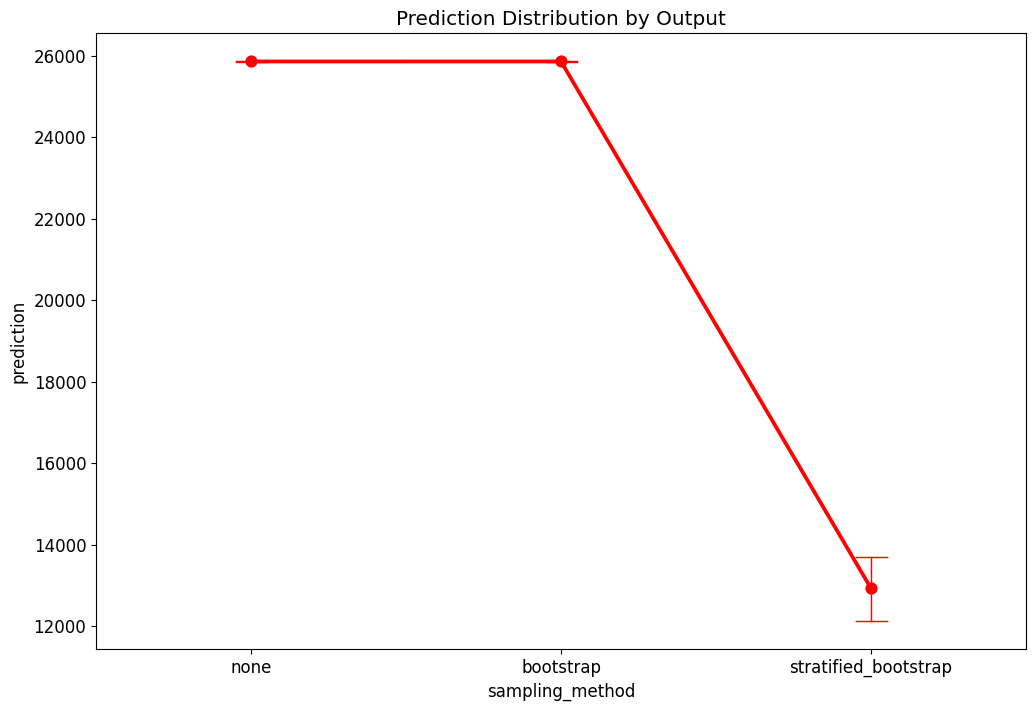

In [198]:
# Use seaborn to show line plot with confidence intervals.
print(wide_pred_df.shape)

# sns.violinplot(
#     data=wide_pred_df[wide_pred_df['output_index'] == 3],
#     x="sampling_method",
#     y="prediction",
#     alpha=0.5,
#     inner=None
# )

# sns.stripplot(
#     data=wide_pred_df[wide_pred_df['output_index'] == 3],
#     x="sampling_method",
#     y="prediction",
#     color='teal',
#     alpha=0.3
# )

sns.pointplot(
    data=wide_pred_df[wide_pred_df['output_index'] == 0],
    x="sampling_method",
    y="prediction",
    estimator="mean",
    errorbar=("ci", 95),   # 95% confidence interval
    err_kws={'linewidth': 1},
    capsize=0.1,
    color='red',
    markers="o",
    linestyles="-"
)

plt.title('Prediction Distribution by Output')
plt.show()

In [ ]:
# Train models - narrow
narrow_Y_pred_sets = random_search_and_get_predictions(narrow_fnn_random_search, "narrow", X_train_sets, Y_train_sets, X_test_sets)
print("model training complete")

In [ ]:
narrow_scores_df = get_scores(narrow_Y_pred_sets, Y_test_sets, "narrow")
narrow_scores_df

In [ ]:
narrow_pred_results_df = get_pred_results(narrow_Y_pred_sets, "narrow")
narrow_pred_results_df

In [ ]:
# Train models - taper/funnel
taper_Y_pred_sets = random_search_and_get_predictions(taper_fnn_random_search, "taper", X_train_sets, Y_train_sets, X_test_sets)
print("model training complete")

In [ ]:
taper_scores_df = get_scores(taper_Y_pred_sets, Y_test_sets, "taper")
taper_scores_df

In [ ]:
taper_pred_results_df = get_pred_results(taper_Y_pred_sets, "taper")
taper_pred_results_df

In [ ]:
# Train models - reverse taper/funnel
rev_taper_Y_pred_sets = random_search_and_get_predictions(rev_taper_fnn_random_search, "rev_taper", X_train_sets, Y_train_sets, X_test_sets)
print("model training complete")

In [ ]:
rev_taper_scores_df = get_scores(rev_taper_Y_pred_sets, Y_test_sets, "rev_taper")
rev_taper_scores_df

In [ ]:
rev_taper_pred_results_df = get_pred_results(rev_taper_Y_pred_sets, "rev_taper")
rev_taper_pred_results_df

In [ ]:
# Train models - bowtie/hourglass
bowtie_Y_pred_sets = random_search_and_get_predictions(bowtie_fnn_random_search, "bowtie", X_train_sets, Y_train_sets, X_test_sets)
print("model training complete")

In [ ]:
bowtie_scores_df = get_scores(bowtie_Y_pred_sets, Y_test_sets, "bowtie")
bowtie_scores_df

In [ ]:
bowtie_pred_results_df = get_pred_results(bowtie_Y_pred_sets, "bowtie")
bowtie_pred_results_df